# Spatial | Allocentric Boundary Distance
-----------------------------------------

## Setup and Configuration

In [1]:
##### Imports ##########################################################################

#==== Generic Imports ================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

#==== Movement Imports ===============
import movement.kinematics

#==== DataConduit Imports (Core) =====
from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement     # Combine aligned pose and confidence in movement format.

#==== DataConduit Imports (Unique) ===
from movement_figures.data_template.loading import build_datastructure
from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from data_conduit.refactor_qc import (
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    filter_trials,
)

#==== Imports for This Figure =========
import movement.roi

#==== Time-Series Annotations =========
from collections.abc import Callable
from movement_figures.timeseries_template.annotations import (
    AnnotationResult,
    annotate_qc_timeseries,
)

### Notebook Settings ######################################################

pd.set_option('display.max_columns', None)                         # Show all trial columns during inspection.
pd.set_option('display.max_rows', None)


In [2]:
##### Setup Parameters #################################################################

# === 1| Select Mice, Days and Recording Folders Before Reading Files =============
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                                       # Example choices belong here: l0_selector and l1_selector.
# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                                # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                            # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                        # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                          # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering.


In [3]:
##### Load DataStructure ###############################################################

#=== Load data ========================================================================

fig_ds_obj = build_datastructure(
    root               = ROOT,                                                                 # Directory above the named hierarchy levels.
    level_names        = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams            = ("trials", "session_settings", "video", "dlc"),                       # Data streams to be included in the datastructure.
    include            = None,                                                                 # Keep these session folder names; None keeps all.
    exclude            = None,                                                                 # Alternatively omit these session folder names.
    raw_events         = True,                                                                 # Convenience alias for adding "events" to the requested sources.
    device_yaml        = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml     = "./soundcard.yml",                                                    # Lab SoundCard register definitions.
    nosepoke_count     = 18,                                                                   # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                                  # Preserve the existing lab parser setting.
    dlc_file_format     = "auto",                                                              # Existing reader prefers CSV, otherwise HDF5.
    trial_spec = None,                                                                         # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.
    
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds_obj.select()
streams = fig_ds_obj.load()                                                                    # Load is required to access the selected streams.

#=== Create convenient compact trial dataframe without some unnecessary columns. ======
streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                                                   # Whether to modify the trial dataframe in place or return a new dataframe. 
)
'''More useful for visual inspection and analysis. 
Check the misc.py file for the default columns to keep and drop.'''


#=== Apply Trial Filtering Protocol to construct new stream objects ===================

# Full filtered trials
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

# Filtered compact trials 
streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"],   
                #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], 
                 #selectors={"session": session_id}
    ),
)

#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,                                                                # Loaded dataset object containing all streams of interest.
    show_stream_shapes = True,                                                                 # Whether to display the shapes of the streams.
    show_stream_dtypes = True,                                                                 # Whether to display the data types of the streams.
    display_streams = False                                                                    # Whether to display the actual stream data as a table.
)



     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


## Select Trials to Show

In [4]:
##### Trial Selection ##################################################################

#==== Extract Trial Range ============
selected_trials = slice_stream(streams['filtered_trials'][:8])              # Select the first n trials

#==== Extract Recording Identifier ===
sessionID = selected_trials['session'].unique().item()                      # Extract unique sID from selected trials, remove duplicates, ensure single value.

#==== Select Tracked Positions =======
recording = slice_stream(stream = streams['dlc:movement'],                  # selectors{} here keeps movement data belonging to the specified session only.
                        selectors = {'session' : sessionID }, 
)

position = recording['position']                                            # ['position'] extracts positional data from the movement stream.

position = position.sel(individual='individual_0',                          # .sel() selects the specified individual from the positional data.
                        drop=True,                                          # drop=True removes the individual dimension from the resulting DataArray, but leaves other dims intact.
)


## Define ROI

Load the arena polygon in the same pixel coordinates as `position`. As in the egocentric notebook, the file and region name are explicit; no arena geometry is inferred from the tracked positions.

In [5]:
##### Load the Region of Interest ######################################################

#==== Specify the Saved Arena ==========
ROI_PATH = Path('../ROI/boundary.geojson')                           # Saved ROI file for this recording.
ROI_NAME = 'region'                                               # Exact name of the arena polygon.

#==== Select the Named ROI =============
ROIs = movement.roi.load_rois(file=ROI_PATH)
ROIs_by_name = {ROI.name: ROI for ROI in ROIs}
arena_roi = ROIs_by_name[ROI_NAME]


## Compute Head-Centre to Boundary Distance

This is the shortest distance from the **ear midpoint to the nearest arena wall**, not an angle and not the distance from the animal to the arena centre. `boundary_only=True` excludes the filled polygon interior.

Reference: [movement ROI distance](https://movement.neuroinformatics.dev/latest/api/movement.roi.BaseRegionOfInterest.html#movement.roi.BaseRegionOfInterest.compute_distance_to).

In [6]:
##### Compute Boundary Distance Using `movement` #######################################

#==== Locate the Ear Midpoint ==========
left_ear = position.sel(keypoint='lear', drop=True)
right_ear = position.sel(keypoint='rear', drop=True)
head_position = (left_ear + right_ear) / 2                        # Use both ears to locate the head centre.


#==== Measure the Nearest Wall =========
boundary_distance = arena_roi.compute_distance_to(
    head_position,
    boundary_only = True,                                        # Measure to the wall, not the polygon's interior.
)
boundary_distance.name = 'head_centre_to_boundary_distance'
boundary_distance.attrs['units'] = 'pixels'


#==== Slice to Selected Range ===========
selected_boundary_distance = boundary_distance                   # None keeps the complete recording trace.
if selected_trials is not None:
    selected_boundary_distance = slice_stream_per_trial(
        stream     = boundary_distance,
        trials     = selected_trials,
        segment    = 'trial',
        time_coord = 'time',
    )
    selected_boundary_distance = xr.concat(selected_boundary_distance, dim='time')


## Boundary Distance Plotting Function

In [7]:
def add_annotations(ax,
                    selected_trials,
                    **kwargs
) -> AnnotationResult:
    """Add trial annotations to an axis using recording seconds.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis with its time limits already set.
    selected_trials : pandas.DataFrame
        Trial rows from the recording being plotted.
    **kwargs
        Arguments passed to annotate_qc_timeseries.

    Returns
    -------
    AnnotationResult
        The annotation artists, legend handles and notes.
    """
    return annotate_qc_timeseries(ax=ax, trials=selected_trials, **kwargs)


In [8]:
##### Plot Boundary Distance on Ax #####################################################


def plot_ax_boundary_distance(
    ax: plt.Axes,
    boundary_distance: xr.DataArray,
    selected_trials: pd.DataFrame | None = None,
    spatial_unit: str = 'Pixels',
    pixel_unit_conv_metric: float | None = None,
    row_duration: float | None = 60.0,
    subtitle: str | None = 'Head-Centre to Boundary Distance',
    add_annotations_func: Callable[..., AnnotationResult] | None = add_annotations,
    annotation_kwargs: dict | None = None,
    **kwargs,
) -> plt.Axes:
    """Plot precomputed boundary distances in consecutive time rows.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis reserved for the plot. The caller sets the figure size.
    boundary_distance : xarray.DataArray
        Nonempty distance trace in pixels, with ordered time in seconds.
    selected_trials : pandas.DataFrame or None
        Optional trial rows for annotations; does not select plotted samples.
    spatial_unit : str
        Distance unit displayed on the y axis.
    pixel_unit_conv_metric : float or None
        Output distance units per pixel. None leaves distances unchanged.
    row_duration : float or None
        Recording seconds per row. None uses the full range on one row.
    subtitle : str or None
        Title above the first row. None omits it.
    add_annotations_func : callable or None
        Default helper uses selected_trials and is skipped without trials.
        Custom callbacks receive only the axis and annotation_kwargs.
    annotation_kwargs : dict or None
        Callback settings. Supply default-helper trials via selected_trials.
    **kwargs
        Arguments passed to Axes.plot, such as markersize and alpha.

    Returns
    -------
    matplotlib.axes.Axes
        Original axis; multiple time rows are available through ax.child_axes.
    """
    #==== 1| Calculate Rows Needed for Subplot =======================
    range_start = float(boundary_distance.time[0])
    range_end = float(boundary_distance.time[-1])

    duration = row_duration
    if duration is None:
        duration = (range_end - range_start) or 1.0                # Give a lone sample a one-second row.
    row_count = max(1, int(np.ceil((range_end - range_start) / duration)))


    #==== 2| Create the Required Time Rows ===========================
    if row_count == 1:
        row_axes = [ax]
    else:
        ax.set_axis_off()                                        # The original axis contains the individual rows.
        row_axes = []
        row_height = 1 / (row_count + 0.25 * (row_count - 1))
        row_gap = 0.25 * row_height                              # Leave room below each row for time labels.

        for row in range(row_count):
            bottom = 1 - (row + 1) * row_height - row * row_gap
            row_axes.append(ax.inset_axes([0, bottom, 1, row_height]))

    for row_ax in row_axes[1:]:
        row_ax.sharey(row_axes[0])                               # Keep distance directly comparable between rows.


    #==== 3| Convert the Distance Units ==============================
    adjusted_distance = boundary_distance
    if pixel_unit_conv_metric is not None:
        adjusted_distance = adjusted_distance * pixel_unit_conv_metric


    #==== 4| Plot Distances and Matching Annotations =================
    annotation_kwargs = annotation_kwargs or {}

    for row, row_ax in enumerate(row_axes):
        row_start = range_start + row * duration
        row_end = min(row_start + duration, range_end)
        row_distance = adjusted_distance.sel(time=slice(row_start, row_end))

        row_ax.plot(row_distance.time, row_distance, '.', **kwargs)  # Do not connect excluded trial intervals.
        row_ax.set(xlim=(row_start, row_start + duration),
                   xlabel='Time (Seconds)', ylabel=f'Boundary Distance ({spatial_unit})')

        # Pass trial rows once to the default helper; custom callbacks use their own kwargs.
        if add_annotations_func is add_annotations:
            if selected_trials is not None:
                add_annotations_func(row_ax, selected_trials, **annotation_kwargs)
        elif add_annotations_func is not None:
            add_annotations_func(row_ax, **annotation_kwargs)

    # The annotation helper restores its previous limits; rescale after every row is drawn.
    row_axes[0].autoscale(axis='y')
    row_axes[0].set_ylim(bottom=0)


    #==== 5| Add the Plot Title ======================================
    if subtitle is not None:
        row_axes[0].set_title(subtitle)

    return ax


## Generate Plot

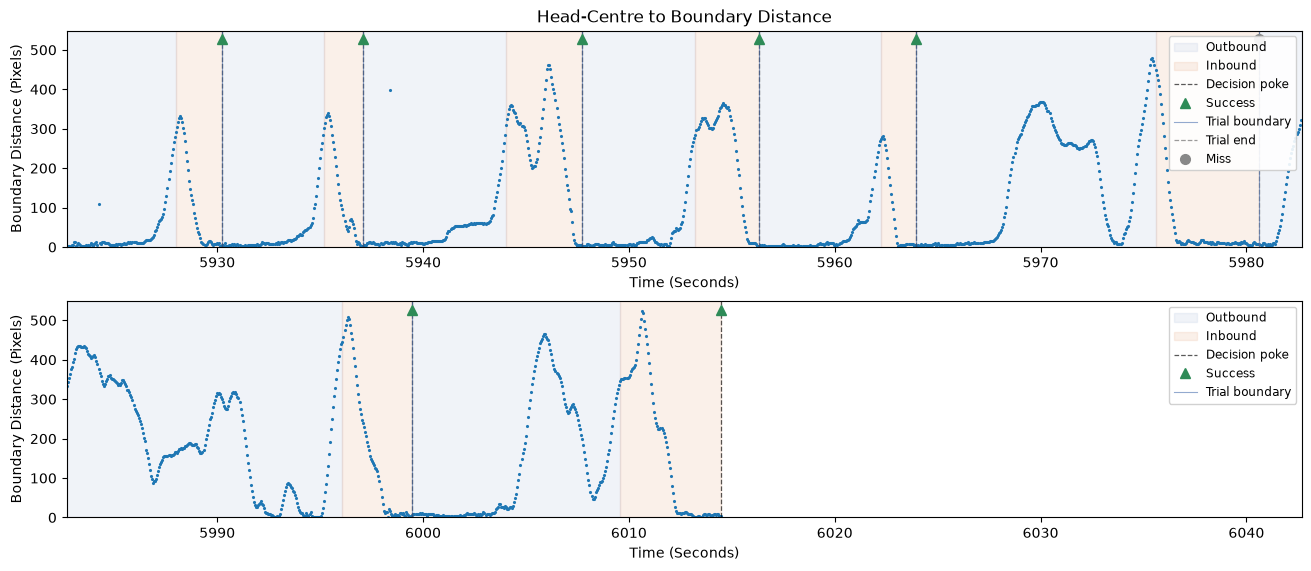

In [9]:
##### Plot the Selected Boundary Distance ##############################################

#==== Size the Figure for the Time Rows =
row_duration = 60.0
plot_duration = float(selected_boundary_distance.time[-1] - selected_boundary_distance.time[0])
row_count = max(1, int(np.ceil(plot_duration / row_duration)))
fig, ax = plt.subplots(figsize=(13, 2.8 * row_count), layout='constrained')


#==== Draw Distance and Annotations =====
ax = plot_ax_boundary_distance(
    ax                     = ax,
    boundary_distance      = selected_boundary_distance,
    selected_trials        = selected_trials,                    # None omits trial annotations.
    spatial_unit           = 'Pixels',
    pixel_unit_conv_metric = None,                               # Output distance units per pixel, when calibrated.
    row_duration           = row_duration,
    add_annotations_func   = add_annotations,
    annotation_kwargs      = None,
    markersize             = 2.5,
)

fig.savefig('boundary_distance_figure.svg', bbox_inches='tight')
plt.show()


## Optional: Arena-Centre to Boundary Distance

The meeting note did not specify which centre. The trace above uses the head centre. A measured **arena centre** gives a separate, fixed distance to the nearest wall; for a circular arena it is the radius. Supply that coordinate below only to calculate this additional value.

In [10]:
##### Measure from the Fixed Arena Centre ##############################################

arena_centre_px = None                                           # Replace with the measured (x, y) arena centre.

if arena_centre_px is not None:
    arena_centre_boundary_distance = arena_roi.compute_distance_to(
        arena_centre_px,
        boundary_only=True,
    )
    print(f'Arena centre to nearest wall: {float(arena_centre_boundary_distance):.3f} pixels')
